# Per-stage prediction-pipeline latency benchmark

Measures how long **each stage** of the prediction pipeline takes, so the cascade
`decision.threshold` can be tuned against the speed/quality trade-off.

The cost lives almost entirely in each stage's **live `collect()`**:

| stage | `collect()` does | rough cost |
|-------|------------------|------------|
| `url`     | nothing (works from the URL string) | sub-millisecond |
| `domain`  | DNS + IP/GeoIP + RDAP/WHOIS (5 s timeout) | ~seconds |
| `content` | HTTP fetch + TLS handshake (10 s `tls_timeout`, 200 KB cap) | ~seconds |

It runs **live collection** against a labeled URL set it sources itself — phishing from the
PhishTank feed (rows flagged `online` **and** `verified`), benign from Google-Trends search via
DuckDuckGo. Every enabled stage runs on **every** URL (cascade early-exit bypassed), each
`collect/extract/predict` phase is timed, and every attempt is classified into an **outcome**
(`ok` / `unreachable` / `timeout` / `feature_error` / `model_error`).

**Read the numbers this way:** the latency stats are **conditional on a successful collection**
(`outcome == "ok"`); failed/timed-out attempts are *excluded from the timings* but counted in the
**outcome-rate** report so the failure picture stays explicit. `degraded` marks successful-but-empty
collections (e.g. a domain that resolved to no IPs, or a non-2xx page). Numbers reflect the current
(sequential, per-URL-bootstrap) collector and the sampled URL mix — not necessarily production.

In [1]:
import os, sys, time, csv, socket, warnings
from io import StringIO
from datetime import datetime, timezone, timedelta
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import display

# Make the project importable when the kernel's cwd is the repo root.
sys.path.insert(0, os.path.abspath("."))

import phishing_engine.stages  # noqa: F401  (registers url/domain/content stages)
from phishing_engine.core.config import load_config
from phishing_engine.core.registry import build_stages
from phishing_engine.core.urls import normalize_url, extract_domain
from phishing_engine.core.pipeline import PipelineContext
# Reused URL sources (run standalone, no Mongo):
from phishing_engine.collectors.sources.phishtank import (
    PHISHTANK_URL, PHISHTANK_HEADERS, _parse_iso_datetime)
from phishing_engine.collectors.sources.search import load_search_terms, iter_search_results

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
print("imports ok")

imports ok


## Parameters

In [2]:
CONFIG_PATH = "config/pipeline.json"
OUTPUT_DIR  = "eval_results"

# --- URL sourcing ---
URL_SOURCE  = os.environ.get("PHISH_LATENCY_SOURCE", "fetch")     # "fetch" | "file"
URLS_FILE   = os.environ.get("PHISH_LATENCY_URLS", "urls_for_latency.csv")
N_PHISH     = int(os.environ.get("PHISH_LATENCY_NPHISH", "150"))  # online+verified phishing URLs
N_BENIGN    = int(os.environ.get("PHISH_LATENCY_NBENIGN", "150")) # benign search URLs
PHISHTANK_DAYS     = None        # set e.g. 3 to keep only recently verification_time'd entries
GTRENDS_PATH       = "g-trends.csv"
SEARCH_MAX_RESULTS = 5           # benign URLs requested per search term

# --- benchmark ---
MAX_URLS    = int(os.environ.get("PHISH_LATENCY_MAX", "0"))       # 0 = all
# NOTE: the domain/content stages take a few seconds each, so a full run is roughly
# (N_PHISH + N_BENIGN) x a few seconds -> minutes-scale. Lower N for a quick smoke run.
print(f"URL_SOURCE={URL_SOURCE!r}  N_PHISH={N_PHISH}  N_BENIGN={N_BENIGN}  URLS_FILE={URLS_FILE!r}")

URL_SOURCE='fetch'  N_PHISH=150  N_BENIGN=150  URLS_FILE='urls_for_latency.csv'


## Build the prediction pipeline (real models loaded)

In [3]:
config = load_config(CONFIG_PATH)
POSITIVE = config.pipeline.decision.positive_label   # "phish"

# build_stages attaches a real ModelRunner wherever the model file exists (production path).
all_stages = build_stages(config.pipeline.stages)
stages = [s for s in all_stages if s.config.enabled]

for s in stages:
    if s.model_runner is not None and hasattr(s.model_runner.model, "verbose"):
        s.model_runner.model.verbose = 0


def stage_timeout_ms(stage):
    """Network ceiling for a stage's collect(), in ms (None for the url stage)."""
    if hasattr(stage, "tls_timeout"):   # content
        return stage.tls_timeout * 1000.0
    if hasattr(stage, "timeout"):       # domain
        return stage.timeout * 1000.0
    return None


TIMEOUT_MS = {s.stage_id: stage_timeout_ms(s) for s in stages}

print("enabled stages (in cascade order):")
for s in stages:
    has_model = "yes" if s.model_runner is not None else "no (feature-only)"
    print(f"  {s.stage_id:8s} model={has_model:18s} collect_timeout_ms={TIMEOUT_MS[s.stage_id]}")

enabled stages (in cascade order):
  url      model=yes                collect_timeout_ms=None
  content  model=yes                collect_timeout_ms=10000.0
  domain   model=yes                collect_timeout_ms=5000.0


## Source & label the URLs

In [4]:
def fetch_phishtank_online_verified(limit, days=None):
    """Return PhishTank URLs the feed marks online AND verified (optionally recent).

    fetch_phishtank_urls() drops the online/verified columns, so we read the feed ourselves.
    requests follows the Cloudflare -> signed-CDN redirect automatically.
    """
    resp = requests.get(PHISHTANK_URL, headers=PHISHTANK_HEADERS, timeout=30, verify=False)
    resp.raise_for_status()
    cutoff = datetime.now(timezone.utc) - timedelta(days=days) if days else None
    urls = []
    for row in csv.DictReader(StringIO(resp.text)):
        url = (row.get("url") or "").strip()
        if not url:
            continue
        if (row.get("online") or "").strip().lower() != "yes":
            continue
        if (row.get("verified") or "").strip().lower() != "yes":
            continue
        if cutoff is not None:
            vt = _parse_iso_datetime(row.get("verification_time") or "")
            if vt and vt < cutoff:
                continue
        urls.append(url)
        if limit and len(urls) >= limit:
            break
    return urls


def fetch_benign_search_urls(terms_path, n, max_results):
    """Collect up to n unique benign URLs from Google-Trends terms via DuckDuckGo."""
    terms = load_search_terms(terms_path)
    seen, out = set(), []
    for _term, urls in iter_search_results(terms, max_results=max_results):
        for u in urls:
            if u and u not in seen:
                seen.add(u)
                out.append(u)
                if len(out) >= n:
                    return out
    return out


if URL_SOURCE == "fetch":
    print("sourcing phishing URLs from PhishTank (online & verified)...")
    phish_urls = fetch_phishtank_online_verified(N_PHISH, days=PHISHTANK_DAYS)
    print(f"  kept {len(phish_urls)} online+verified phishing URLs")

    print("sourcing benign URLs from Google-Trends via DuckDuckGo...")
    benign_urls = fetch_benign_search_urls(GTRENDS_PATH, N_BENIGN, SEARCH_MAX_RESULTS)
    print(f"  kept {len(benign_urls)} benign URLs")
    if len(benign_urls) < N_BENIGN:
        print(f"  (warning: wanted {N_BENIGN} benign URLs; DuckDuckGo may have rate-limited)")

    labeled = [(u, "phish") for u in phish_urls] + [(u, "benign") for u in benign_urls]
    seen, rows = set(), []                       # de-dup across the whole set (first label wins)
    for u, lab in labeled:
        if u not in seen:
            seen.add(u)
            rows.append((u, lab))
    with open(URLS_FILE, "w", newline="", encoding="utf-8") as fh:
        w = csv.writer(fh)
        w.writerow(["url", "label"])
        w.writerows(rows)
    print(f"wrote {len(rows)} labeled URLs -> {URLS_FILE}")
else:
    print(f"URL_SOURCE={URL_SOURCE!r}: skipping sourcing; reading existing {URLS_FILE!r}")

sourcing phishing URLs from PhishTank (online & verified)...
  kept 150 online+verified phishing URLs
sourcing benign URLs from Google-Trends via DuckDuckGo...
  kept 150 benign URLs
wrote 300 labeled URLs -> urls_for_latency.csv


## Load the labeled URLs

In [5]:
def load_labeled_urls(path):
    """Load (url, label) pairs from a CSV (url[,label]) or a plain-text file (one URL/line)."""
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"URL file not found: {path!r}. Set URL_SOURCE='fetch' to create it, or point "
            f"URLS_FILE at a CSV (url[,label]) / text file.")
    rows = []
    if path.lower().endswith(".csv"):
        df = pd.read_csv(path)
        ucol = "url" if "url" in df.columns else df.columns[0]
        has_label = "label" in df.columns
        for _, r in df.iterrows():
            u = str(r[ucol]).strip()
            if not u or u.lower() == "nan":
                continue
            lab = str(r["label"]).strip() if has_label and pd.notna(r["label"]) else "unknown"
            rows.append((u, lab))
    else:
        with open(path, encoding="utf-8") as fh:
            for ln in fh:
                u = ln.strip()
                if u and not u.startswith("#"):
                    rows.append((u, "unknown"))
    seen, out = set(), []                        # de-dup, preserve order
    for u, lab in rows:
        if u not in seen:
            seen.add(u)
            out.append((u, lab))
    return out


url_records = load_labeled_urls(URLS_FILE)
if MAX_URLS:
    url_records = url_records[:MAX_URLS]
print(f"loaded {len(url_records)} URLs from {URLS_FILE!r}: "
      f"{dict(Counter(lab for _, lab in url_records))}")

loaded 300 URLs from 'urls_for_latency.csv': {'phish': 150, 'benign': 150}


## Per-stage timing helper + benchmark loop

In [6]:
def classify_collect_exc(exc):
    """Map a collect() exception to an outcome: 'timeout' / 'unreachable' / 'error'."""
    if isinstance(exc, requests.exceptions.Timeout) or isinstance(exc, (socket.timeout, TimeoutError)):
        return "timeout"
    if isinstance(exc, requests.exceptions.ConnectionError):
        return "unreachable"
    name = type(exc).__name__.lower()
    if "timeout" in name:
        return "timeout"
    if any(k in name for k in ("connect", "resolve", "dns", "unreachable", "connection", "ssl", "network")):
        return "unreachable"
    if isinstance(exc, requests.exceptions.RequestException):
        return "unreachable"
    return "error"


def time_stage(stage, ctx):
    """Run one stage's collect -> extract -> predict on `ctx`, timing each phase (ms).

    Records an explicit `outcome` (ok / unreachable / timeout / feature_error / model_error),
    which phase failed, and a `degraded` flag for successful-but-hollow collections. Latency
    fields are filled per phase; only `ok` rows feed the latency stats downstream.
    """
    rec = {"stage": stage.stage_id, "collect_ms": None, "extract_ms": None,
           "predict_ms": None, "total_ms": None, "p_phish": None,
           "outcome": "ok", "phase_failed": None, "degraded": False,
           "near_timeout": False, "status_code": None, "error": None}
    artifacts, features = {}, None
    t_all = time.perf_counter()
    phase = "collect"
    try:
        t = time.perf_counter()
        artifacts = stage.collect(ctx)
        rec["collect_ms"] = (time.perf_counter() - t) * 1000.0

        phase = "extract"
        t = time.perf_counter()
        features = stage.extract_features(ctx, artifacts)
        rec["extract_ms"] = (time.perf_counter() - t) * 1000.0

        if stage.model_runner is not None:
            phase = "predict"
            t = time.perf_counter()
            pred = stage.predict(features, artifacts)
            rec["predict_ms"] = (time.perf_counter() - t) * 1000.0
            rec["p_phish"] = pred.probabilities.get(POSITIVE)
    except Exception as exc:
        rec["phase_failed"] = phase
        rec["error"] = f"{type(exc).__name__}: {exc}"
        rec["outcome"] = (classify_collect_exc(exc) if phase == "collect"
                          else "feature_error" if phase == "extract" else "model_error")
    rec["total_ms"] = (time.perf_counter() - t_all) * 1000.0

    # slow-but-ok collect approaching the stage ceiling (a swallowed internal timeout)
    ceil = TIMEOUT_MS.get(stage.stage_id)
    rec["near_timeout"] = bool(ceil and rec["collect_ms"] and rec["collect_ms"] >= 0.9 * ceil)

    # degraded: a successful collection that returned nothing useful (stays outcome="ok")
    if rec["outcome"] == "ok" and isinstance(artifacts, dict):
        if stage.stage_id == "content":
            sc = artifacts.get("status_code")
            rec["status_code"] = sc
            html = artifacts.get("html") or ""
            rec["degraded"] = (sc is None) or not (200 <= sc < 400) or (len(html) == 0)
        elif stage.stage_id == "domain":
            record = artifacts.get("record") or {}
            remarks = record.get("remarks") or {}
            rec["degraded"] = (len(record.get("ip_data") or []) == 0) or bool(remarks.get("dns_had_no_ips"))
    return rec


# The domain stage's collect() calls asyncio.run(), which raises inside Jupyter's already
# -running event loop. Running each stage in a single reused worker thread (no running loop)
# sidesteps that while keeping timing accurate and stages sequential.
_pool = ThreadPoolExecutor(max_workers=1)

rows = []
for i, (url, label) in enumerate(tqdm(url_records, desc="benchmarking", unit="url")):
    norm = normalize_url(url)
    ctx = PipelineContext(url=url, normalized_url=norm, domain=extract_domain(norm))
    for stage in stages:                         # every enabled stage on every URL
        rec = _pool.submit(time_stage, stage, ctx).result()
        rec["url"] = url
        rec["label"] = label
        rows.append(rec)

per_url = pd.DataFrame(rows)
per_url = per_url[["url", "label", "stage", "collect_ms", "extract_ms", "predict_ms", "total_ms",
                   "p_phish", "outcome", "phase_failed", "degraded", "near_timeout",
                   "status_code", "error"]]
print(f"collected {len(per_url)} (url, stage) timing rows")
per_url.head(len(stages) * 2)

benchmarking: 100%|██████████| 300/300 [18:54<00:00,  3.78s/url] 

collected 900 (url, stage) timing rows


,url,label,stage,collect_ms,extract_ms,predict_ms,total_ms,p_phish,outcome,phase_failed,degraded,near_timeout,status_code,error
0,https://allegro.pl-676.sbs,phish,url,0.000713,1679.227788,3.896971,1683.131681,0.999070,ok,NaN,False,False,NaN,NaN
1,https://allegro.pl-676.sbs,phish,content,1150.004560,73.708543,170.753289,1394.472540,0.200000,ok,NaN,False,False,200.0,NaN
2,https://allegro.pl-676.sbs,phish,domain,4649.098418,86.460615,27.025488,4762.589985,0.999151,ok,NaN,False,True,NaN,NaN
3,https://aumentoja0005.s3.us-east-005.backblaze...,phish,url,0.000639,7.222513,1.926913,9.153987,0.999877,ok,NaN,False,False,NaN,NaN
4,https://aumentoja0005.s3.us-east-005.backblaze...,phish,content,714.294158,18.341498,157.287881,889.928618,1.000000,ok,NaN,True,False,403.0,NaN
5,https://aumentoja0005.s3.us-east-005.backblaze...,phish,domain,1672.859712,84.549790,23.998526,1781.413214,0.999688,ok,NaN,False,False,NaN,NaN


## Latency summaries (overall + by label) and outcome rates

In [7]:
PHASES = ["collect_ms", "extract_ms", "predict_ms", "total_ms"]
OUTCOMES = ["ok", "unreachable", "timeout", "feature_error", "model_error"]
STAGE_ORDER = [s.stage_id for s in stages]


def _pctl(s, q):
    s = s.dropna()
    return round(float(np.percentile(s, q)), 2) if len(s) else float("nan")


def _stat(s, fn):
    s = s.dropna()
    return round(float(fn(s)), 2) if len(s) else float("nan")


def _ordered(df):
    df["stage"] = pd.Categorical(df["stage"], categories=STAGE_ORDER, ordered=True)
    keys = [c for c in ("stage", "label") if c in df.columns]
    return df.sort_values(keys).reset_index(drop=True)


def summarize(frame, group_cols):
    """Success-only (outcome=='ok') per-(group x phase) latency stats; ms."""
    out = []
    for keys, g in frame.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        base = dict(zip(group_cols, keys))
        ok = g[g["outcome"] == "ok"]
        counts = {"n_ok": int((g["outcome"] == "ok").sum()),
                  "n_error": int((g["outcome"] != "ok").sum()),
                  "n_near_timeout": int(g["near_timeout"].sum())}
        for phase in PHASES:
            vals = ok[phase]
            out.append({**base, "phase": phase.replace("_ms", ""),
                        "count": int(vals.dropna().shape[0]),
                        "mean_ms": _stat(vals, np.mean), "median_ms": _stat(vals, np.median),
                        "p95_ms": _pctl(vals, 95), "min_ms": _stat(vals, np.min),
                        "max_ms": _stat(vals, np.max), **counts})
    return _ordered(pd.DataFrame(out))


def outcome_rates(frame, group_cols):
    """Outcome counts + percentages per group, plus degraded/near_timeout rates."""
    out = []
    for keys, g in frame.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        n = len(g)
        row = {**dict(zip(group_cols, keys)), "n_total": n}
        for oc in OUTCOMES:
            c = int((g["outcome"] == oc).sum())
            row[f"n_{oc}"] = c
            row[f"pct_{oc}"] = round(100.0 * c / n, 1) if n else 0.0
        ok = g[g["outcome"] == "ok"]
        row["n_degraded"] = int(g["degraded"].sum())
        row["degraded_pct"] = round(100.0 * int(g["degraded"].sum()) / n, 1) if n else 0.0
        row["near_timeout_pct_of_ok"] = round(100.0 * int(ok["near_timeout"].sum()) / len(ok), 1) if len(ok) else 0.0
        out.append(row)
    return _ordered(pd.DataFrame(out))


summary           = summarize(per_url, ["stage"])
by_label          = summarize(per_url, ["stage", "label"])
outcomes          = outcome_rates(per_url, ["stage"])
outcomes_by_label = outcome_rates(per_url, ["stage", "label"])

print("Overall per-stage latency (ok rows only; ms):")
display(summary)
print("\nPer-stage latency by label (phishing vs benign; ms):")
display(by_label)
print("\nPer-stage outcome rates (how often each stage succeeds/fails):")
display(outcomes)

Overall per-stage latency (ok rows only; ms):


,stage,phase,count,mean_ms,median_ms,p95_ms,min_ms,max_ms,n_ok,n_error,n_near_timeout
0,url,collect,300,0.00,0.00,0.00,0.00,0.01,300,0,0
1,url,extract,300,11.51,4.00,17.23,0.92,1679.23,300,0,0
2,url,predict,300,1.94,1.80,2.70,1.49,9.49,300,0,0
3,url,total,300,13.45,5.78,21.70,2.73,1683.13,300,0,0
4,content,collect,245,652.48,461.72,1739.76,127.36,3728.20,245,55,0
5,content,extract,245,46.67,39.54,78.37,16.07,268.41,245,55,0
6,content,predict,245,157.63,155.52,177.24,131.89,186.67,245,55,0
7,content,total,245,856.79,676.47,1908.46,299.10,3920.10,245,55,0
8,domain,collect,300,2813.09,2166.26,6897.84,410.96,10024.42,300,0,61
9,domain,extract,300,90.84,83.47,108.93,75.23,267.82,300,0,61



Per-stage latency by label (phishing vs benign; ms):


,stage,label,phase,count,mean_ms,median_ms,p95_ms,min_ms,max_ms,n_ok,n_error,n_near_timeout
0,url,benign,collect,150,0.00,0.00,0.00,0.00,0.01,150,0,0
1,url,benign,extract,150,7.13,5.43,15.18,1.40,22.07,150,0,0
2,url,benign,predict,150,2.01,1.85,2.71,1.55,9.49,150,0,0
3,url,benign,total,150,9.14,7.41,18.59,3.30,24.51,150,0,0
4,url,phish,collect,150,0.00,0.00,0.00,0.00,0.00,150,0,0
5,url,phish,extract,150,15.89,3.38,25.18,0.92,1679.23,150,0,0
6,url,phish,predict,150,1.87,1.74,2.47,1.49,4.92,150,0,0
7,url,phish,total,150,17.76,5.13,27.07,2.73,1683.13,150,0,0
8,content,benign,collect,149,608.37,440.66,1622.49,138.85,3266.58,149,1,0
9,content,benign,extract,149,54.91,49.12,88.38,17.51,268.41,149,1,0



Per-stage outcome rates (how often each stage succeeds/fails):


,stage,n_total,n_ok,pct_ok,n_unreachable,pct_unreachable,n_timeout,pct_timeout,n_feature_error,pct_feature_error,n_model_error,pct_model_error,n_degraded,degraded_pct,near_timeout_pct_of_ok
0,url,300,300,100.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0.0
1,content,300,245,81.7,51,17.0,4,1.3,0,0.0,0,0.0,42,14.0,0.0
2,domain,300,300,100.0,0,0.0,0,0.0,0,0.0,0,0.0,51,17.0,20.3


## How to read these numbers (caveats)

- **Latency is conditional on a successful collection** (`outcome == "ok"`). Attempts that were
  `unreachable`, `timeout`, `feature_error`, or `model_error` are **excluded** from the `mean/median/
  p95` — but they are fully quantified in the outcome-rate tables above (and `latency_outcomes.csv`),
  so the failure picture is explicit rather than hidden.
- **`degraded`** marks successful-but-hollow `ok` collections (a domain that resolved to no IPs, or a
  content fetch with a non-2xx status / empty HTML). These stay in the latency stats but are flagged
  so you can see/exclude fast-but-meaningless collections.
- **`near_timeout`** flags slow `ok` collections approaching the stage's ceiling (a swallowed internal
  timeout). Note the domain collect runs several sequential sub-timeout phases, so it can exceed a
  single ceiling without any one operation timing out.
- Numbers reflect the **current (sequential, per-URL-bootstrap) collector** and **this sampled URL
  mix** (PhishTank online+verified skews toward still-live hosts; Google-Trends benign skews to big
  media sites). They are not reweighted to production traffic.

## Plots

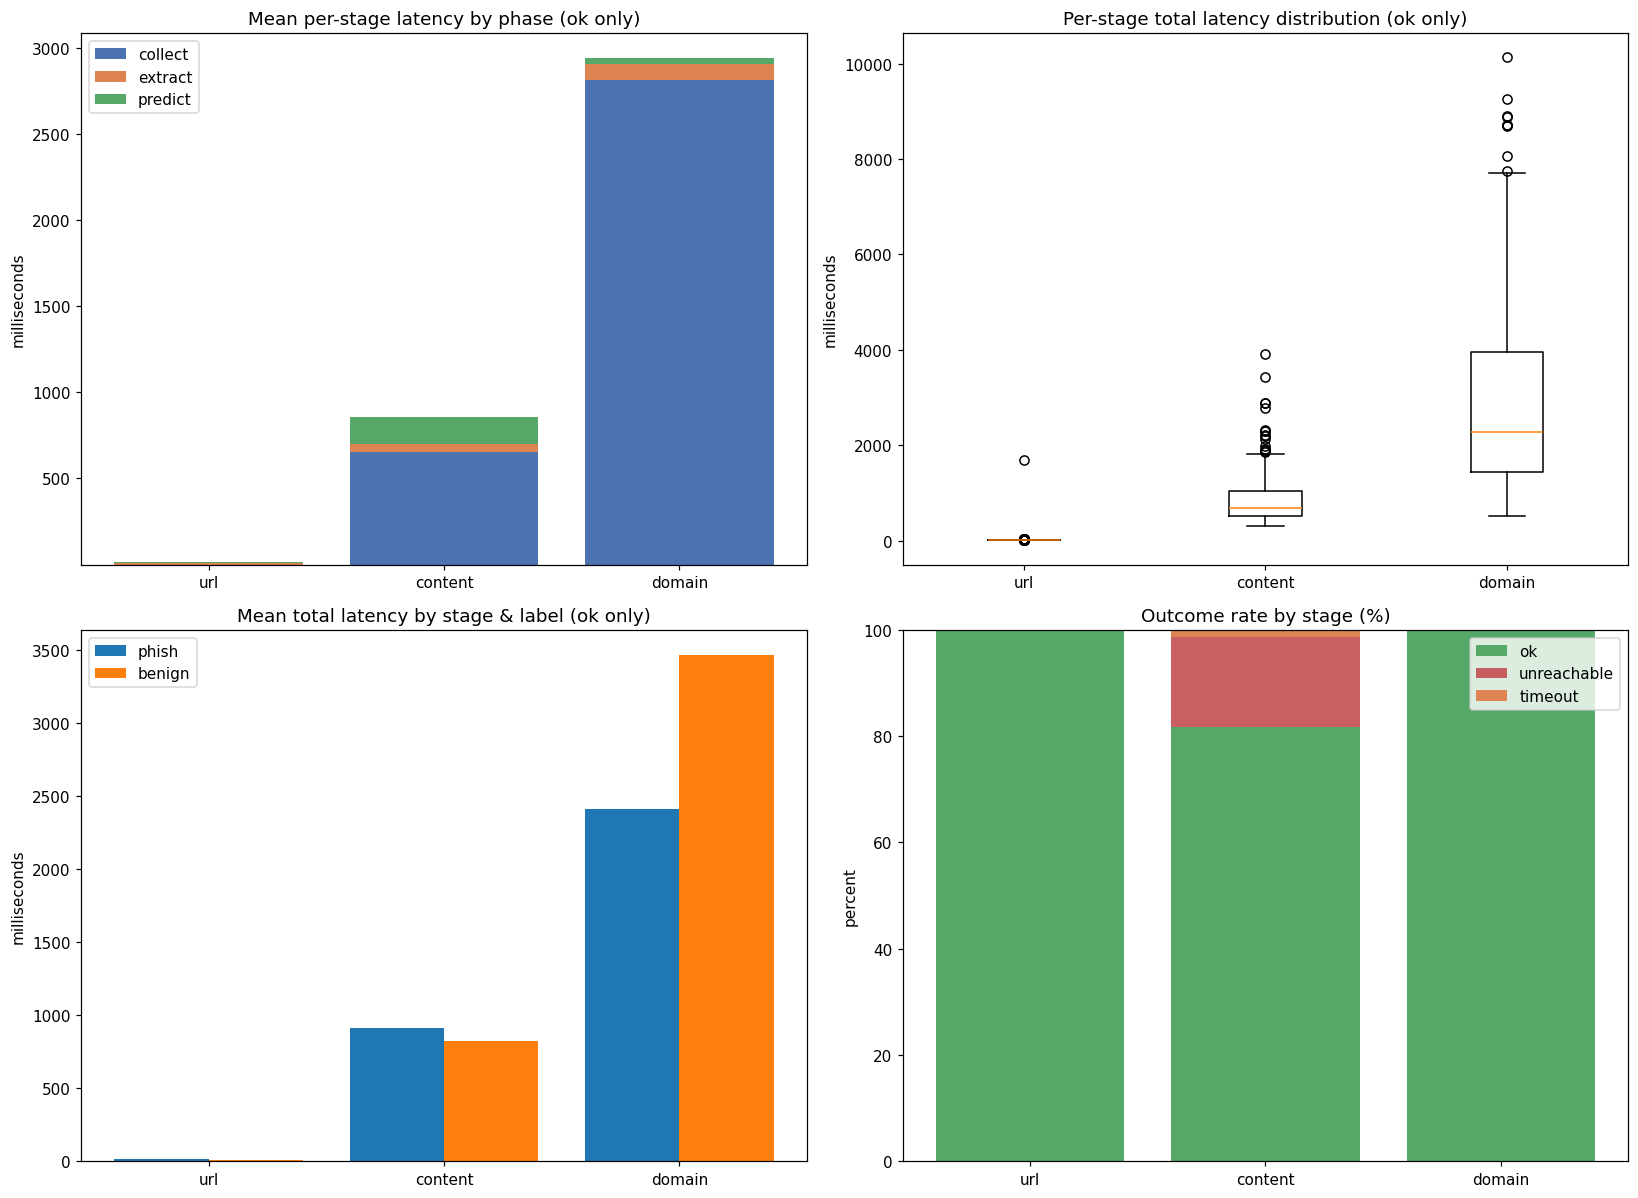

In [8]:
ok = per_url[per_url["outcome"] == "ok"]
means = (ok.groupby("stage")[["collect_ms", "extract_ms", "predict_ms"]]
           .mean().reindex(STAGE_ORDER))
labels_present = [l for l in ["phish", "benign"] if l in per_url["label"].unique()]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1) mean per-stage latency, stacked by phase (ok only)
ax = axes[0, 0]
bottom = np.zeros(len(STAGE_ORDER))
for phase, color in [("collect_ms", "#4C72B0"), ("extract_ms", "#DD8452"), ("predict_ms", "#55A868")]:
    vals = means[phase].fillna(0).to_numpy()
    ax.bar(STAGE_ORDER, vals, bottom=bottom, label=phase.replace("_ms", ""), color=color)
    bottom += vals
ax.set_title("Mean per-stage latency by phase (ok only)")
ax.set_ylabel("milliseconds")
ax.legend()

# 2) distribution of total per-stage latency (ok only)
ax = axes[0, 1]
data = [ok[ok["stage"] == sid]["total_ms"].dropna().to_numpy() for sid in STAGE_ORDER]
ax.boxplot(data, labels=STAGE_ORDER, showfliers=True)
ax.set_title("Per-stage total latency distribution (ok only)")
ax.set_ylabel("milliseconds")

# 3) mean total latency by stage, phishing vs benign (ok only)
ax = axes[1, 0]
x = np.arange(len(STAGE_ORDER))
w = 0.8 / max(1, len(labels_present))
for j, lab in enumerate(labels_present):
    sub = ok[ok["label"] == lab]
    mt = sub.groupby("stage")["total_ms"].mean().reindex(STAGE_ORDER).fillna(0).to_numpy()
    ax.bar(x + j * w, mt, width=w, label=lab)
ax.set_xticks(x + w * (len(labels_present) - 1) / 2)
ax.set_xticklabels(STAGE_ORDER)
ax.set_title("Mean total latency by stage & label (ok only)")
ax.set_ylabel("milliseconds")
ax.legend()

# 4) outcome-rate stacked bar per stage (%)
ax = axes[1, 1]
oc = outcomes.set_index("stage").reindex(STAGE_ORDER)
bottom = np.zeros(len(STAGE_ORDER))
for name, color in [("ok", "#55A868"), ("unreachable", "#C44E52E6"), ("timeout", "#DD8452"),
                    ("feature_error", "#8172B3"), ("model_error", "#937860")]:
    col = f"pct_{name}"
    vals = oc[col].fillna(0).to_numpy() if col in oc.columns else np.zeros(len(STAGE_ORDER))
    if vals.sum() > 0:
        ax.bar(STAGE_ORDER, vals, bottom=bottom, label=name, color=color)
        bottom += vals
ax.set_title("Outcome rate by stage (%)")
ax.set_ylabel("percent")
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

## Save results

In [9]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
paths = {
    "per_url": os.path.join(OUTPUT_DIR, "latency_per_url.csv"),
    "summary": os.path.join(OUTPUT_DIR, "latency_summary.csv"),
    "by_label": os.path.join(OUTPUT_DIR, "latency_by_label.csv"),
    "outcomes": os.path.join(OUTPUT_DIR, "latency_outcomes.csv"),
}
per_url.to_csv(paths["per_url"], index=False)
summary.to_csv(paths["summary"], index=False)
by_label.to_csv(paths["by_label"], index=False)
outcomes_by_label.to_csv(paths["outcomes"], index=False)
print(f"saved {len(per_url)} timing rows -> {paths['per_url']}")
print(f"saved overall summary        -> {paths['summary']}")
print(f"saved by-label summary       -> {paths['by_label']}")
print(f"saved outcome rates          -> {paths['outcomes']}")

saved 900 timing rows -> eval_results/latency_per_url.csv
saved overall summary        -> eval_results/latency_summary.csv
saved by-label summary       -> eval_results/latency_by_label.csv
saved outcome rates          -> eval_results/latency_outcomes.csv
